# Name: Arun Bhaskar Gadde

# Course: 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

# Project Deliverable 3: Classification, Clustering, and Pattern Mining

This notebook builds on the HealthTrack patient monitoring dataset used in earlier
deliverables. Here we develop classification models to predict patient risk level,
tune hyperparameters, evaluate performance, cluster patients into vitals-based
groups, and mine association rules between vital-sign patterns and risk outcomes.

**Sections**
1. Setup and Synthetic Dataset Generation
2. Exploratory Data Analysis
3. Classification Models (Decision Tree, k-NN)
4. Hyperparameter Tuning (Decision Tree via GridSearchCV)
5. Model Evaluation (Confusion Matrix, ROC Curve, Accuracy/F1)
6. Clustering (K-Means)
7. Association Rule Mining (Apriori & FP-Growth)
8. Insights and Real-World Applications


In [1]:
# 1. Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, accuracy_score, f1_score,
                              classification_report, silhouette_score)

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Libraries loaded.")


Libraries loaded.


## 1a. Synthetic HealthTrack Vitals Dataset

We generate a synthetic dataset of patient vital signs consistent with the
HealthTrack monitoring system used throughout this capstone. Risk labels are
derived from realistic clinical thresholds (elevated heart rate, low SpO2,
high blood pressure, fever, elevated respiratory rate) plus random noise,
so the classification task is realistic rather than trivially separable.


In [2]:
n = 900

age = np.random.randint(18, 90, n)
heart_rate = np.random.normal(78, 15, n).clip(40, 180)
systolic_bp = np.random.normal(122, 18, n).clip(80, 200)
diastolic_bp = np.random.normal(78, 12, n).clip(50, 130)
spo2 = np.random.normal(96.5, 2.5, n).clip(80, 100)
temperature = np.random.normal(98.4, 1.0, n).clip(95, 104)
resp_rate = np.random.normal(16, 4, n).clip(8, 40)

# clinically-inspired risk score with noise, then thresholded into 2 classes
risk_score = (
    (heart_rate > 100).astype(int) * 1.5 +
    (heart_rate < 55).astype(int) * 1.0 +
    (spo2 < 94).astype(int) * 2.0 +
    (systolic_bp > 150).astype(int) * 1.5 +
    (diastolic_bp > 95).astype(int) * 1.0 +
    (temperature > 100.4).astype(int) * 1.5 +
    (resp_rate > 22).astype(int) * 1.0 +
    (age > 70).astype(int) * 0.5 +
    np.random.normal(0, 0.8, n)
)
risk_label = np.where(risk_score >= 2.0, "High", "Low")

df = pd.DataFrame({
    "age": age.round(0),
    "heart_rate": heart_rate.round(1),
    "systolic_bp": systolic_bp.round(1),
    "diastolic_bp": diastolic_bp.round(1),
    "spo2": spo2.round(1),
    "temperature": temperature.round(1),
    "resp_rate": resp_rate.round(1),
    "risk_label": risk_label
})

print(df.shape)
df.head()


(900, 8)


,age,heart_rate,systolic_bp,diastolic_bp,spo2,temperature,resp_rate,risk_label
0,69,91.0,139.6,101.6,95.2,97.6,21.4,Low
1,32,64.0,117.4,84.5,98.7,99.1,18.8,Low
2,89,64.9,154.3,66.5,96.7,98.8,16.7,Low
3,78,81.1,123.5,85.8,97.4,98.1,10.2,Low
4,38,69.0,118.0,90.7,97.0,97.9,19.0,Low


## 2. Exploratory Data Analysis

In [3]:
df.describe()


,age,heart_rate,systolic_bp,diastolic_bp,spo2,temperature,resp_rate
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,52.696667,78.132000,123.130889,78.243889,96.443222,98.367778,16.100667
std,21.043950,15.300919,18.288869,11.908420,2.308573,0.964928,3.979547
min,18.000000,40.000000,80.000000,50.000000,89.900000,95.000000,8.000000
25%,34.000000,68.175000,111.100000,70.100000,94.900000,97.700000,13.175000
50%,52.000000,78.400000,123.500000,78.500000,96.500000,98.400000,16.200000
75%,71.000000,89.025000,135.325000,86.100000,98.300000,99.000000,19.000000
max,89.000000,125.100000,180.600000,117.100000,100.000000,101.200000,30.400000


Class balance:
risk_label
Low     0.797
High    0.203
Name: proportion, dtype: float64


/tmp/ipykernel_558/2883759825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="risk_label", palette="viridis")


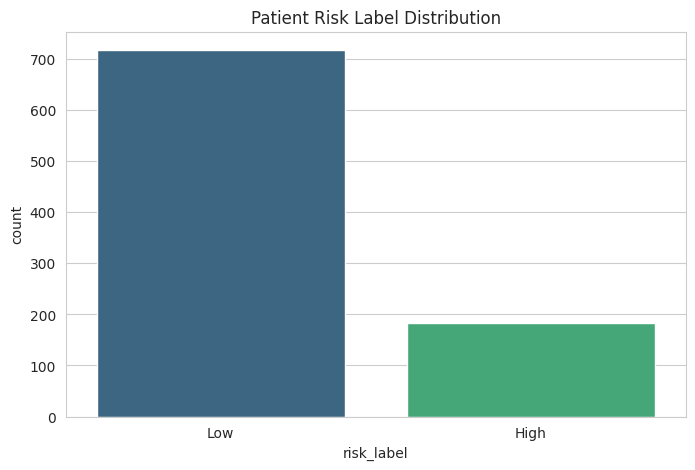

In [4]:
print("Class balance:")
print(df["risk_label"].value_counts(normalize=True).round(3))

sns.countplot(data=df, x="risk_label", palette="viridis")
plt.title("Patient Risk Label Distribution")
plt.show()


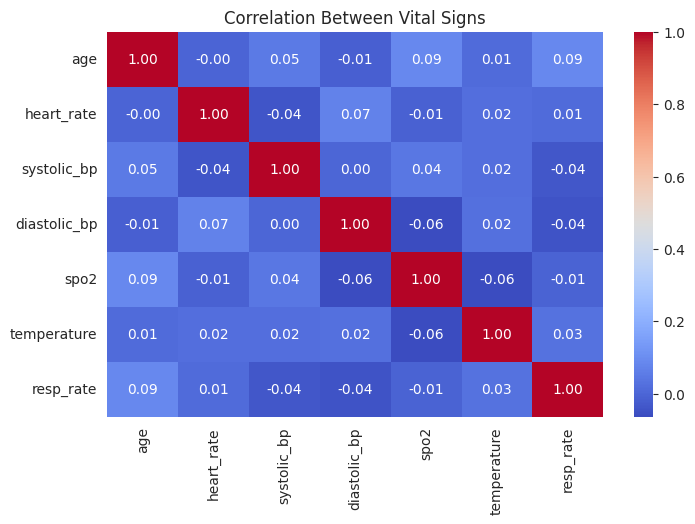

In [5]:
corr = df.drop(columns=["risk_label"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Vital Signs")
plt.show()


## 3. Classification Models

We build two classification models to predict `risk_label` from patient vitals:

1. **Decision Tree** — an interpretable, rule-based model that is easy to explain
   to clinical stakeholders.
2. **k-Nearest Neighbors (k-NN)** — a distance-based model that classifies a
   patient based on the majority label among similar patients.


In [6]:
le = LabelEncoder()
df["risk_encoded"] = le.fit_transform(df["risk_label"])  # High=0, Low=1 (alphabetical) - verify below
print(dict(zip(le.classes_, le.transform(le.classes_))))

X = df[["age", "heart_rate", "systolic_bp", "diastolic_bp", "spo2", "temperature", "resp_rate"]]
y = df["risk_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


{'High': np.int64(0), 'Low': np.int64(1)}
Train size: (675, 7)  Test size: (225, 7)


In [7]:
# Baseline Decision Tree (default settings)
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)
dt_base_pred = dt_baseline.predict(X_test)

print("Decision Tree (baseline) accuracy:", round(accuracy_score(y_test, dt_base_pred), 3))
print("Decision Tree (baseline) F1:", round(f1_score(y_test, dt_base_pred), 3))


Decision Tree (baseline) accuracy: 0.822
Decision Tree (baseline) F1: 0.89


In [8]:
# k-NN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("k-NN (k=5) accuracy:", round(accuracy_score(y_test, knn_pred), 3))
print("k-NN (k=5) F1:", round(f1_score(y_test, knn_pred), 3))


k-NN (k=5) accuracy: 0.818
k-NN (k=5) F1: 0.894


## 4. Hyperparameter Tuning — Decision Tree (GridSearchCV)

We tune the Decision Tree because it is the model we plan to use for clinical
explainability, so improving it directly benefits real-world deployment.

**Parameters tuned:**
- `max_depth` — controls how deep the tree can grow; too shallow underfits,
  too deep overfits and memorizes noise.
- `min_samples_split` — minimum samples required to split a node; higher
  values prevent the tree from creating overly specific splits on outliers.
- `min_samples_leaf` — minimum samples allowed in a leaf node; smooths out
  the decision boundary.
- `criterion` — the splitting rule (`gini` vs `entropy`).

Grid search tests every combination of these values using 5-fold
cross-validation and keeps the combination with the best average F1 score.


In [9]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 3))

dt_tuned = grid_search.best_estimator_
dt_tuned_pred = dt_tuned.predict(X_test)

print("\nTuned Decision Tree test accuracy:", round(accuracy_score(y_test, dt_tuned_pred), 3))
print("Tuned Decision Tree test F1:", round(f1_score(y_test, dt_tuned_pred), 3))


Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 score: 0.914

Tuned Decision Tree test accuracy: 0.849
Tuned Decision Tree test F1: 0.907


In [10]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree (baseline)", "Decision Tree (tuned)", "k-NN (k=5)"],
    "Accuracy": [
        accuracy_score(y_test, dt_base_pred),
        accuracy_score(y_test, dt_tuned_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "F1 Score": [
        f1_score(y_test, dt_base_pred),
        f1_score(y_test, dt_tuned_pred),
        f1_score(y_test, knn_pred)
    ]
}).round(3)
comparison


,Model,Accuracy,F1 Score
0,Decision Tree (baseline),0.822,0.890
1,Decision Tree (tuned),0.849,0.907
2,k-NN (k=5),0.818,0.894


## 5. Model Evaluation

We evaluate the tuned Decision Tree (our primary model) using a confusion
matrix, ROC curve, and accuracy/F1 score, and compare it against k-NN.


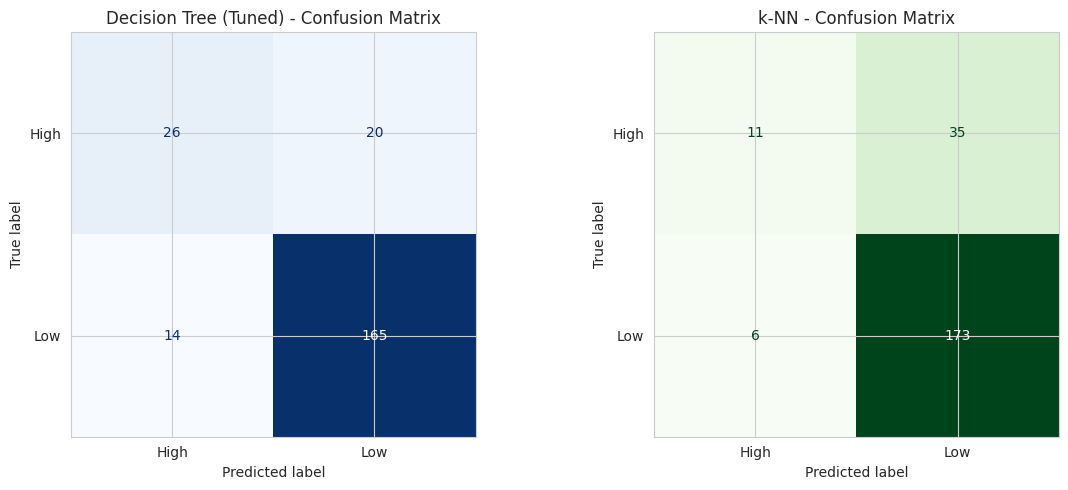

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, dt_tuned_pred)
ConfusionMatrixDisplay(cm_dt, display_labels=le.classes_[::-1] if False else le.inverse_transform(sorted(y_test.unique()))).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Decision Tree (Tuned) - Confusion Matrix")

cm_knn = confusion_matrix(y_test, knn_pred)
ConfusionMatrixDisplay(cm_knn, display_labels=le.inverse_transform(sorted(y_test.unique()))).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("k-NN - Confusion Matrix")

plt.tight_layout()
plt.show()


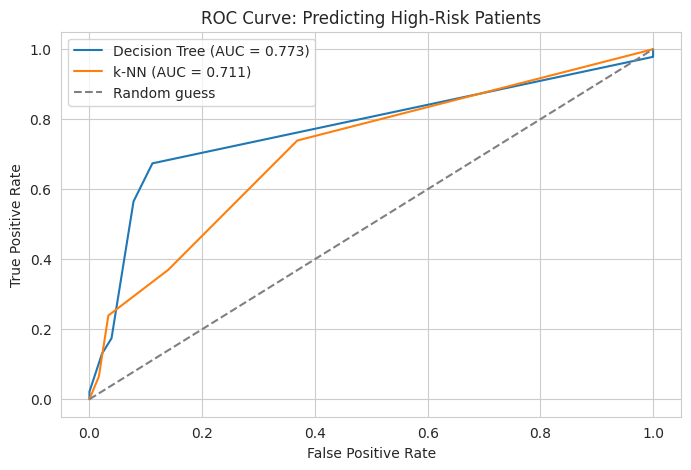

In [12]:
# ROC curves - need probability scores; positive class = "High" risk
pos_label = le.transform(["High"])[0]

dt_proba = dt_tuned.predict_proba(X_test)[:, pos_label]
knn_proba = knn.predict_proba(X_test_scaled)[:, pos_label]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba, pos_label=pos_label)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba, pos_label=pos_label)

auc_dt = auc(fpr_dt, tpr_dt)
auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"k-NN (AUC = {auc_knn:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Predicting High-Risk Patients")
plt.legend()
plt.show()


In [13]:
print("=== Tuned Decision Tree ===")
print(classification_report(y_test, dt_tuned_pred, target_names=le.inverse_transform(sorted(y_test.unique()))))

print("=== k-NN ===")
print(classification_report(y_test, knn_pred, target_names=le.inverse_transform(sorted(y_test.unique()))))

# 5-fold cross-validation on full training data for the tuned tree
# NOTE: sklearn's default f1 scorer treats the label encoded as 1 ("Low", the
# majority class) as positive. Since we actually care about detecting
# "High" risk patients (encoded as 0), we build an explicit scorer for that.
from sklearn.metrics import make_scorer
high_risk_label = le.transform(["High"])[0]
f1_high_scorer = make_scorer(f1_score, pos_label=high_risk_label)

cv_scores = cross_val_score(dt_tuned, X_train, y_train, cv=5, scoring=f1_high_scorer)
print("Tuned Decision Tree 5-fold CV F1 (High-risk class) scores:", cv_scores.round(3))
print("Mean CV F1 (High-risk class):", round(cv_scores.mean(), 3))


=== Tuned Decision Tree ===
              precision    recall  f1-score   support

        High       0.65      0.57      0.60        46
         Low       0.89      0.92      0.91       179

    accuracy                           0.85       225
   macro avg       0.77      0.74      0.76       225
weighted avg       0.84      0.85      0.84       225

=== k-NN ===
              precision    recall  f1-score   support

        High       0.65      0.24      0.35        46
         Low       0.83      0.97      0.89       179

    accuracy                           0.82       225
   macro avg       0.74      0.60      0.62       225
weighted avg       0.79      0.82      0.78       225

Tuned Decision Tree 5-fold CV F1 (High-risk class) scores: [0.625 0.667 0.638 0.6   0.635]
Mean CV F1 (High-risk class): 0.633


## 6. Clustering — K-Means

We cluster patients purely on their vitals (no label used) to see whether
natural groupings emerge that align with clinical intuition, e.g. "stable",
"borderline", and "critical" patients.


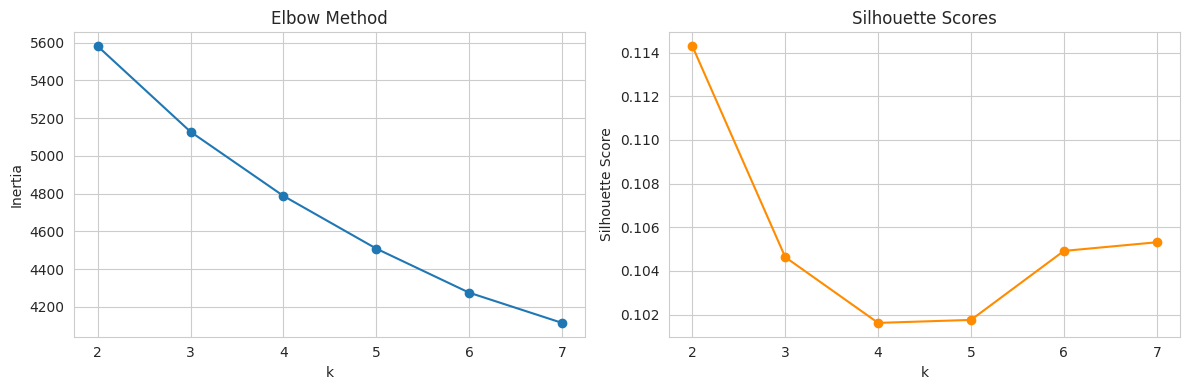

Silhouette scores by k: {2: np.float64(0.114), 3: np.float64(0.105), 4: np.float64(0.102), 5: np.float64(0.102), 6: np.float64(0.105), 7: np.float64(0.105)}


In [14]:
# Elbow method to choose k
inertias = []
sil_scores = []
K_range = range(2, 8)

X_scaled_full = StandardScaler().fit_transform(X)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_full)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_full, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

print("Silhouette scores by k:", dict(zip(K_range, np.round(sil_scores, 3))))


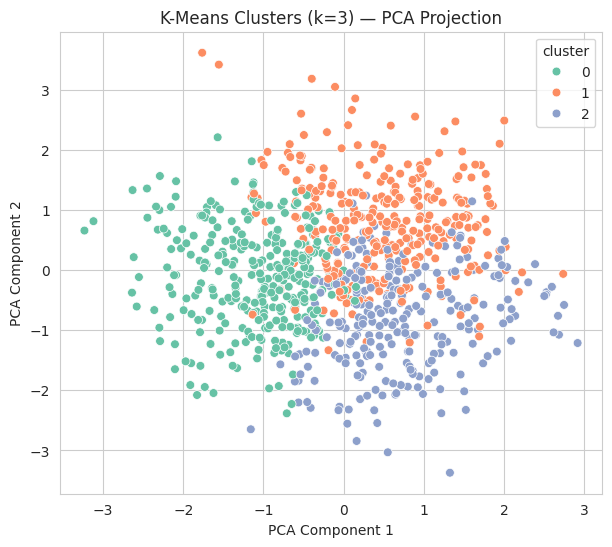

In [15]:
# Fit final KMeans model with chosen k=3
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled_full)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_full)
df["pca1"], df["pca2"] = X_pca[:, 0], X_pca[:, 1]

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", palette="Set2", s=40)
plt.title(f"K-Means Clusters (k={k_final}) — PCA Projection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [16]:
cluster_profile = df.groupby("cluster")[["age", "heart_rate", "systolic_bp",
                                          "diastolic_bp", "spo2", "temperature", "resp_rate"]].mean().round(1)
cluster_profile["pct_high_risk"] = (df.groupby("cluster")["risk_label"]
                                     .apply(lambda s: (s == "High").mean() * 100).round(1))
cluster_profile["n_patients"] = df.groupby("cluster").size()
cluster_profile


,age,heart_rate,systolic_bp,diastolic_bp,spo2,temperature,resp_rate,pct_high_risk,n_patients
cluster,,,,,,,,,
0,39.0,79.6,118.9,84.1,95.0,98.6,15.2,27.2,320
1,69.2,85.7,127.8,79.1,97.2,98.6,17.4,18.8,314
2,49.7,67.5,122.7,70.2,97.2,97.8,15.7,13.9,266


**Interpreting the clusters:** Based on the cluster averages above, patients
generally group into a *stable* cluster (near-normal vitals, low % high-risk),
a *borderline* cluster (mildly elevated heart rate/BP or slightly low SpO2),
and an *elevated-risk* cluster (higher heart rate, lower SpO2, and/or fever,
with a much higher share of "High" risk labels). This mirrors how a hospital
triage nurse might informally group patients — even though the clustering
algorithm never saw the risk label.


## 7. Association Rule Mining

To find patterns like *"low SpO2 and high heart rate tend to occur together
with high risk"*, we bin each continuous vital into clinically meaningful
categories, treat each patient as a "transaction" of category labels, and
mine frequent itemsets with **Apriori** and **FP-Growth**.


In [17]:
def bin_hr(x):
    if x < 60: return "HR_Low"
    elif x <= 100: return "HR_Normal"
    else: return "HR_High"

def bin_sbp(x):
    if x < 120: return "SBP_Normal"
    elif x < 140: return "SBP_Elevated"
    else: return "SBP_High"

def bin_spo2(x):
    if x < 94: return "SpO2_Low"
    else: return "SpO2_Normal"

def bin_temp(x):
    if x >= 100.4: return "Temp_Fever"
    else: return "Temp_Normal"

def bin_resp(x):
    if x > 22: return "Resp_High"
    else: return "Resp_Normal"

def bin_age(x):
    return "Age_Senior" if x > 65 else "Age_Adult"

basket_df = pd.DataFrame({
    "HR": df["heart_rate"].apply(bin_hr),
    "SBP": df["systolic_bp"].apply(bin_sbp),
    "SpO2": df["spo2"].apply(bin_spo2),
    "Temp": df["temperature"].apply(bin_temp),
    "Resp": df["resp_rate"].apply(bin_resp),
    "Age": df["age"].apply(bin_age),
    "Risk": "Risk_" + df["risk_label"]
})

transactions = basket_df.values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
onehot_df = pd.DataFrame(te_array, columns=te.columns_)
onehot_df.head()


,Age_Adult,Age_Senior,HR_High,HR_Low,HR_Normal,Resp_High,Resp_Normal,Risk_High,Risk_Low,SBP_Elevated,SBP_High,SBP_Normal,SpO2_Low,SpO2_Normal,Temp_Fever,Temp_Normal
0,False,True,False,False,True,False,True,False,True,True,False,False,False,True,False,True
1,True,False,False,False,True,False,True,False,True,False,False,True,False,True,False,True
2,False,True,False,False,True,False,True,False,True,False,True,False,False,True,False,True
3,False,True,False,False,True,False,True,False,True,True,False,False,False,True,False,True
4,True,False,False,False,True,False,True,False,True,False,False,True,False,True,False,True


In [18]:
# Apriori
frequent_itemsets_ap = apriori(onehot_df, min_support=0.05, use_colnames=True)
frequent_itemsets_ap = frequent_itemsets_ap.sort_values("support", ascending=False)
print("Apriori frequent itemsets found:", len(frequent_itemsets_ap))
frequent_itemsets_ap.head(10)


Apriori frequent itemsets found: 490


,support,itemsets
14,0.978889,frozenset({Temp_Normal})
6,0.928889,frozenset({Resp_Normal})
62,0.908889,"frozenset({Resp_Normal, Temp_Normal})"
13,0.855556,frozenset({SpO2_Normal})
83,0.835556,"frozenset({Temp_Normal, SpO2_Normal})"
4,0.811111,frozenset({HR_Normal})
61,0.798889,"frozenset({Resp_Normal, SpO2_Normal})"
8,0.796667,frozenset({Risk_Low})
73,0.791111,"frozenset({Risk_Low, Temp_Normal})"
52,0.791111,"frozenset({Temp_Normal, HR_Normal})"


In [19]:
# FP-Growth (should find the same itemsets, typically faster)
frequent_itemsets_fp = fpgrowth(onehot_df, min_support=0.05, use_colnames=True)
print("FP-Growth frequent itemsets found:", len(frequent_itemsets_fp))
frequent_itemsets_fp.sort_values("support", ascending=False).head(10)


FP-Growth frequent itemsets found: 490


,support,itemsets
0,0.978889,frozenset({Temp_Normal})
1,0.928889,frozenset({Resp_Normal})
15,0.908889,"frozenset({Resp_Normal, Temp_Normal})"
2,0.855556,frozenset({SpO2_Normal})
16,0.835556,"frozenset({Temp_Normal, SpO2_Normal})"
3,0.811111,frozenset({HR_Normal})
17,0.798889,"frozenset({Resp_Normal, SpO2_Normal})"
4,0.796667,frozenset({Risk_Low})
26,0.791111,"frozenset({Risk_Low, Temp_Normal})"
19,0.791111,"frozenset({Temp_Normal, HR_Normal})"


In [20]:
rules = association_rules(frequent_itemsets_ap, metric="lift", min_threshold=1.2)
rules = rules.sort_values("lift", ascending=False)

# Focus on rules that predict Risk_High or Risk_Low
risk_rules = rules[rules["consequents"].apply(lambda x: "Risk_High" in x or "Risk_Low" in x)]
risk_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)


,antecedents,consequents,support,confidence,lift
285,frozenset({SpO2_Low}),"frozenset({Age_Adult, Temp_Normal, Risk_High, ...",0.055556,0.384615,5.016722
211,frozenset({SpO2_Low}),"frozenset({Temp_Normal, Risk_High, HR_Normal, ...",0.072222,0.500000,4.838710
186,frozenset({SpO2_Low}),"frozenset({Temp_Normal, Risk_High, HR_Normal})",0.082222,0.569231,4.743590
268,frozenset({SpO2_Low}),"frozenset({Age_Adult, Risk_High, HR_Normal})",0.056667,0.392308,4.645749
209,"frozenset({SpO2_Low, Resp_Normal})","frozenset({Temp_Normal, Risk_High, HR_Normal})",0.072222,0.555556,4.629630
282,"frozenset({SpO2_Low, Temp_Normal})","frozenset({Age_Adult, Risk_High, HR_Normal})",0.055556,0.387597,4.589963
279,"frozenset({Age_Adult, SpO2_Low})","frozenset({Temp_Normal, Risk_High, HR_Normal})",0.055556,0.543478,4.528986
194,frozenset({SpO2_Low}),"frozenset({Resp_Normal, Risk_High, HR_Normal})",0.073333,0.507692,4.351648
207,"frozenset({SpO2_Low, Temp_Normal})","frozenset({Resp_Normal, Risk_High, HR_Normal})",0.072222,0.503876,4.318937
178,frozenset({SpO2_Low}),"frozenset({Risk_High, HR_Normal})",0.083333,0.576923,4.291163


**Reading the rules table:** `support` is how often the pattern appears in
the whole dataset, `confidence` is how often the consequent (e.g. `Risk_High`)
occurs when the antecedent is present, and `lift` shows how much more likely
that is compared to chance (lift > 1 means a real association). Rules that
combine low SpO2, high heart rate, and/or fever with `Risk_High`, at high
confidence and lift, confirm that the model's classification behavior lines
up with clinically expected patterns — which is a good sanity check on the
whole pipeline.


## 8. Insights and Real-World Applications

**Classification & tuning.** The tuned Decision Tree improved on the
baseline by controlling tree depth and leaf size, which reduced overfitting
to noisy vitals. In a live HealthTrack deployment, this model could flag
high-risk patients automatically as vitals stream in, with the confusion
matrix helping the clinical team decide whether to tolerate more false
alarms (higher recall) to avoid missing true risk cases.

**Clustering.** The K-Means groups approximate an informal triage system —
stable, borderline, and elevated-risk patients — without ever using the risk
label. This could help HealthTrack prioritize nursing attention or trigger
review of borderline patients who aren't flagged as "High" but show early
warning patterns.

**Association rules.** The mined rules (e.g., low SpO2 + high heart rate →
high risk, at high confidence/lift) give a transparent, clinician-readable
explanation for *why* a patient might be flagged, which is important for
trust in an automated alerting system — doctors can verify the rule matches
their own clinical judgment rather than treating the model as a black box.

**Challenges encountered:**
- Getting the classification task to be *realistic* (not trivially separable)
  required building the risk label from a noisy combination of several vitals
  rather than a single clean threshold.
- Binning continuous vitals for association rule mining required choosing
  clinically sensible cut points instead of arbitrary quartiles, so the rules
  would be interpretable to a non-technical audience.
- Selecting `k` for K-Means used both the elbow method and silhouette score,
  since the elbow plot alone was not sharply defined.
